#### Download library

In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.1 MB/s eta 0:00:00a 0:00:01


#### Seed, Plot, Multi-seed

In [2]:
import os
import random
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch_geometric.utils import to_undirected

from torch_geometric.nn import SAGEConv

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    average_precision_score, confusion_matrix, classification_report
)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def plot_learning_curves(history: dict, model_name: str = "Model") -> None:
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    ax.plot(epochs, history['train_loss'], label='Train Loss')
    ax.plot(epochs, history['val_loss'], label='Val Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{model_name} – Loss')
    ax.legend()
    ax.grid(True)

    ax = axes[1]
    ax.plot(epochs, history['train_f1'], label='Train F1 (illicit)')
    ax.plot(epochs, history['val_f1'], label='Val F1 (illicit)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1-score')
    ax.set_title(f'{model_name} – F1 (illicit)')
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

def run_multiseed(run_single_seed_fn, exp_name="Experiment", seeds=[42, 0, 123]):
    results = []
    for seed in seeds:
        print(f"\n{exp_name} - Seed: {seed}")
        metrics = run_single_seed_fn(seed)
        metrics['seed'] = seed
        results.append(metrics)
        
    print(f"\n {exp_name} multi-seed results")
    metric_keys = [k for k in results[0].keys() if k != 'seed']
    
    for key in metric_keys:
        values = [res[key] for res in results]
        mean_val = np.mean(values)
        std_val = np.std(values)
        
        display_key = {'f1_ill': 'F1(illicit)', 'precision': 'Precision', 'recall': 'Recall', 'auc_pr': 'AUC-PR'}.get(key, key.capitalize())
        print(f"{display_key:<11}: {mean_val:.4f} ± {std_val:.4f}")
        
    return results


#### Data-processing and Architecture

In [3]:
def load_and_preprocess_data(data_path: str, device: torch.device | None = None, undirected: bool = True) -> tuple:
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    data = torch.load(data_path, weights_only=False)
    
    if undirected:
        data.edge_index = to_undirected(data.edge_index)

    train_features = data.x[data.train_mask]
    train_mean = train_features.mean(dim=0)
    train_std = train_features.std(dim=0)
    data.x = (data.x - train_mean) / (train_std + 1e-8)
    print(data)

    data = data.to(device)
    return data, device

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, aggregator_type='max', dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr=aggregator_type)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels, aggr=aggregator_type)
        self.conv3 = SAGEConv(hidden_channels, out_channels, aggr=aggregator_type)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv3(x, edge_index)
        return x

#### Training & Evaluation Logic

In [4]:
def compute_class_weights(data, device: torch.device) -> torch.Tensor:
    n_licit = (data.y[data.train_mask] == 0).sum().item()
    n_illicit = (data.y[data.train_mask] == 1).sum().item()
    weight = torch.tensor([1.0, math.sqrt(n_licit / n_illicit)], dtype=torch.float).to(device)
    return weight

def evaluate(model, data, criterion, mask) -> dict:
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[mask].argmax(dim=1)
        probs = F.softmax(out[mask], dim=1)[:, 1]
        y_true, y_pred, y_prob = data.y[mask].cpu().numpy(), pred.cpu().numpy(), probs.cpu().numpy()
        loss = criterion(out[mask], data.y[mask]).item()

    return {
        'loss': loss, 'accuracy': accuracy_score(y_true, y_pred),
        'precision_ill': precision_score(y_true, y_pred, pos_label=1, zero_division=0), 
        'recall_ill': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_ill': f1_score(y_true, y_pred, pos_label=1, zero_division=0), 
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0), 
        'auc_pr': average_precision_score(y_true, y_prob),
    }

def train_one_epoch(model, data, optimizer, criterion, clip_grad_norm=None):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    if clip_grad_norm is not None:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)
    optimizer.step()
    return loss.item()

def train_with_early_stopping(model, data, optimizer, criterion, save_path: str, num_epochs: int = 200, patience: int = 20, monitor_metric: str = 'f1_ill', clip_grad_norm=None, scheduler=None) -> dict:
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_score, epochs_no_improve, best_epoch = 0.0, 0, 0

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, data, optimizer, criterion, clip_grad_norm=clip_grad_norm)
        train_metrics = evaluate(model, data, criterion, data.train_mask)
        val_metrics = evaluate(model, data, criterion, data.val_mask)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_f1'].append(train_metrics['f1_ill'])
        history['val_f1'].append(val_metrics['f1_ill'])

        if scheduler is not None: scheduler.step()

        if val_metrics[monitor_metric] > best_val_score:
            best_val_score, best_epoch, epochs_no_improve = val_metrics[monitor_metric], epoch, 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1

        print(f"Epoch {epoch:03d}: Train Loss={train_loss:.4f}, Val Loss={val_metrics['loss']:.4f}, Train F1={train_metrics['f1_ill']:.4f}, Val F1={val_metrics['f1_ill']:.4f}, Gap={train_metrics['f1_ill'] - val_metrics['f1_ill']:.4f}")

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (Best epoch: {best_epoch})")
            break
    return history

def print_test_evaluation(model, data, criterion, label: str = "Test") -> None:
    test_metrics = evaluate(model, data, criterion, data.test_mask)
    print(f"{label}\n  Loss          : {test_metrics['loss']:.4f}\n  Accuracy      : {test_metrics['accuracy']:.4f}\n  Precision(ill): {test_metrics['precision_ill']:.4f}\n  Recall(ill)   : {test_metrics['recall_ill']:.4f}\n  F1(illicit)   : {test_metrics['f1_ill']:.4f}\n  F1(macro)     : {test_metrics['f1_macro']:.4f}\n  AUC-PR        : {test_metrics['auc_pr']:.4f}")

    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[data.test_mask].argmax(dim=1)
        y_true, y_pred = data.y[data.test_mask].cpu().numpy(), pred.cpu().numpy()

    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Licit (0)', 'Illicit (1)'], digits=4, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


#### Main execution

Device: cuda
Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
Start training GraphSAGE on Kaggle

GraphSAGE - Seed: 42
GraphSAGE Train - Seed: 42
Epoch 001: Train Loss=0.9149, Val Loss=6.9356, Train F1=0.1734, Val F1=0.1409, Gap=0.0325
Epoch 002: Train Loss=0.8578, Val Loss=5.4872, Train F1=0.1875, Val F1=0.1342, Gap=0.0533
Epoch 003: Train Loss=0.7778, Val Loss=3.9978, Train F1=0.1790, Val F1=0.1275, Gap=0.0516
Epoch 004: Train Loss=0.7587, Val Loss=2.3459, Train F1=0.1570, Val F1=0.1005, Gap=0.0565
Epoch 005: Train Loss=0.6821, Val Loss=0.6308, Train F1=0.1130, Val F1=0.1231, Gap=-0.0101
Epoch 006: Train Loss=0.6434, Val Loss=0.6418, Train F1=0.0549, Val F1=0.0813, Gap=-0.0263
Epoch 007: Train Loss=0.5870, Val Loss=0.6635, Train F1=0.0160, Val F1=0.0660, Gap=-0.0500
Epoch 008: Train Loss=0.5656, Val Loss=0.6949, Train F1=0.0063, Val F1=0.0267, Gap=-0.0204
Epoch 009: Train Loss=0.5450, Val Loss=0.7370, Train F1=0.001

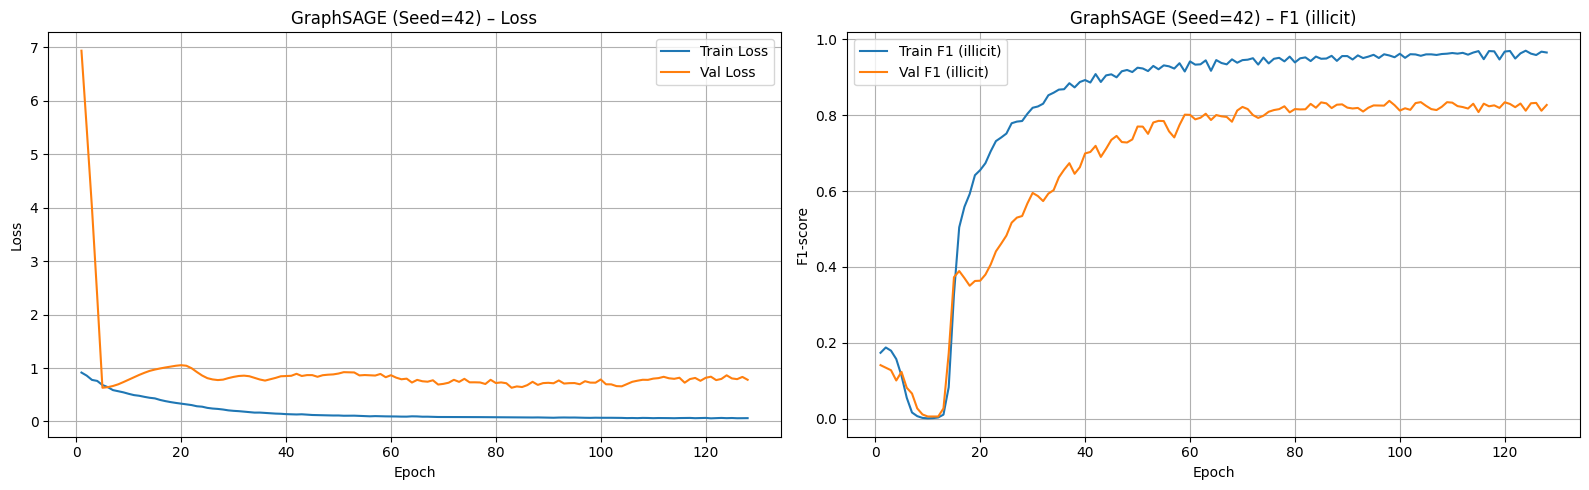

GraphSAGE Test - Seed: 42
  Loss          : 0.5693
  Accuracy      : 0.9581
  Precision(ill): 0.8995
  Recall(ill)   : 0.6369
  F1(illicit)   : 0.7457
  F1(macro)     : 0.8614
  AUC-PR        : 0.7626

Classification Report:
               precision    recall  f1-score   support

   Licit (0)     0.9624    0.9924    0.9772      5132
 Illicit (1)     0.8995    0.6369    0.7457       548

    accuracy                         0.9581      5680
   macro avg     0.9309    0.8146    0.8614      5680
weighted avg     0.9563    0.9581    0.9548      5680

Confusion Matrix:
 [[5093   39]
 [ 199  349]]

GraphSAGE - Seed: 0
GraphSAGE Train - Seed: 0
Epoch 001: Train Loss=0.7169, Val Loss=0.6686, Train F1=0.0833, Val F1=0.0258, Gap=0.0575
Epoch 002: Train Loss=0.6486, Val Loss=0.6747, Train F1=0.0850, Val F1=0.0250, Gap=0.0600
Epoch 003: Train Loss=0.6509, Val Loss=0.6853, Train F1=0.0874, Val F1=0.0177, Gap=0.0697
Epoch 004: Train Loss=0.6123, Val Loss=0.6996, Train F1=0.0850, Val F1=0.0149, Gap=0

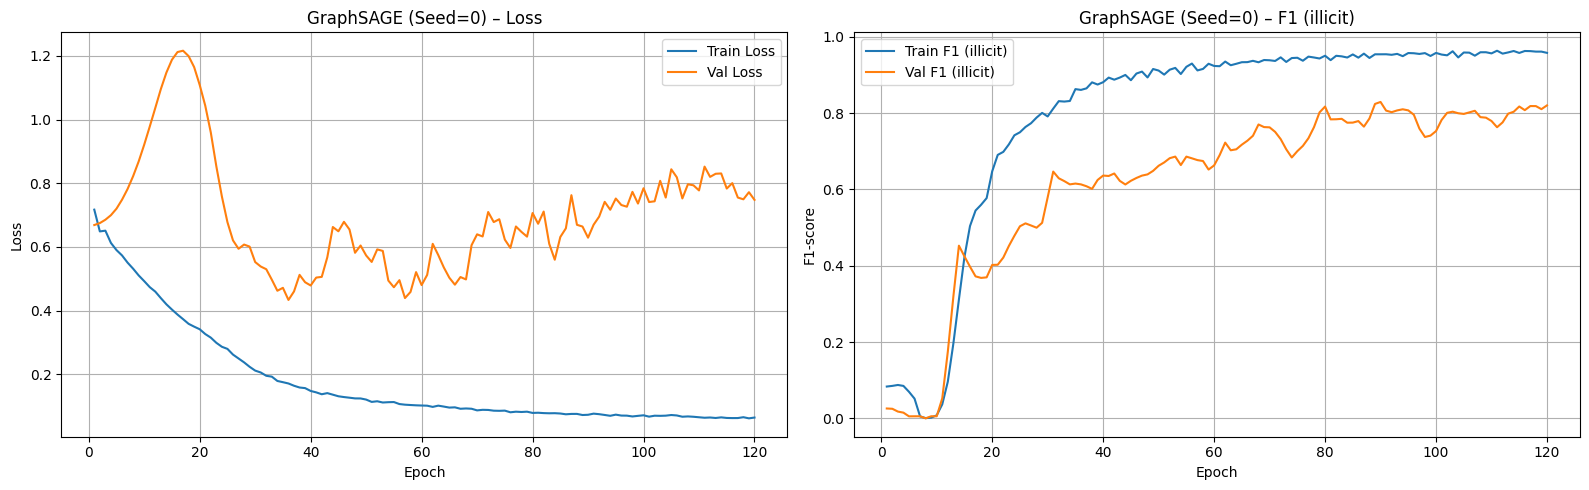

GraphSAGE Test - Seed: 0
  Loss          : 0.6026
  Accuracy      : 0.9526
  Precision(ill): 0.8843
  Recall(ill)   : 0.5858
  F1(illicit)   : 0.7047
  F1(macro)     : 0.8395
  AUC-PR        : 0.7350

Classification Report:
               precision    recall  f1-score   support

   Licit (0)     0.9573    0.9918    0.9743      5132
 Illicit (1)     0.8843    0.5858    0.7047       548

    accuracy                         0.9526      5680
   macro avg     0.9208    0.7888    0.8395      5680
weighted avg     0.9503    0.9526    0.9483      5680

Confusion Matrix:
 [[5090   42]
 [ 227  321]]

GraphSAGE - Seed: 123
GraphSAGE Train - Seed: 123
Epoch 001: Train Loss=1.3622, Val Loss=11.0460, Train F1=0.1609, Val F1=0.1426, Gap=0.0183
Epoch 002: Train Loss=1.3036, Val Loss=9.0903, Train F1=0.1589, Val F1=0.1410, Gap=0.0179
Epoch 003: Train Loss=1.1333, Val Loss=6.7557, Train F1=0.1611, Val F1=0.1452, Gap=0.0159
Epoch 004: Train Loss=0.9991, Val Loss=3.8402, Train F1=0.1630, Val F1=0.1443, G

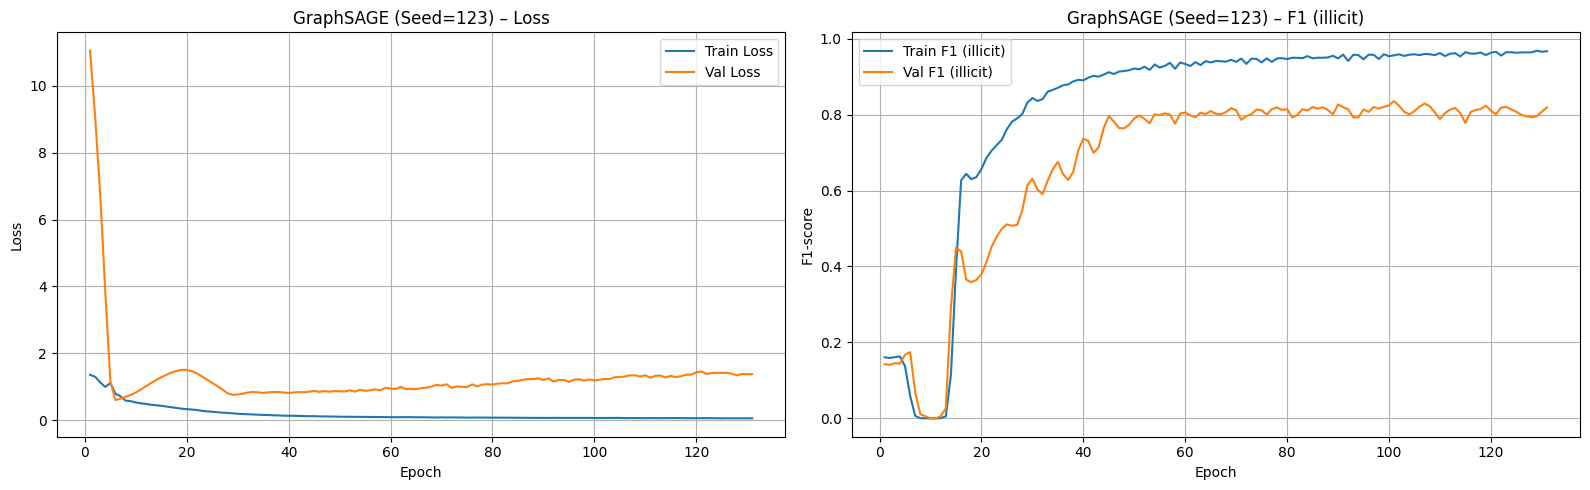

GraphSAGE Test - Seed: 123
  Loss          : 0.5409
  Accuracy      : 0.9537
  Precision(ill): 0.8947
  Recall(ill)   : 0.5894
  F1(illicit)   : 0.7107
  F1(macro)     : 0.8428
  AUC-PR        : 0.7711

Classification Report:
               precision    recall  f1-score   support

   Licit (0)     0.9577    0.9926    0.9748      5132
 Illicit (1)     0.8947    0.5894    0.7107       548

    accuracy                         0.9537      5680
   macro avg     0.9262    0.7910    0.8428      5680
weighted avg     0.9516    0.9537    0.9493      5680

Confusion Matrix:
 [[5094   38]
 [ 225  323]]

 GraphSAGE multi-seed results
Loss       : 0.5709 ± 0.0252
Accuracy   : 0.9548 ± 0.0024
Precision_ill: 0.8928 ± 0.0063
Recall_ill : 0.6040 ± 0.0233
F1(illicit): 0.7204 ± 0.0181
F1_macro   : 0.8479 ± 0.0097
AUC-PR     : 0.7562 ± 0.0154


In [5]:
data_path = '/kaggle/input/datasets/meowll/elliptic-graph-data/elliptic_pyg_data.pt'

data, device = load_and_preprocess_data(data_path, undirected=False)

def run_single_gcn_seed(seed):
    set_seed(seed)
    print(f"GraphSAGE Train - Seed: {seed}")
    
    model = GraphSAGE(
        in_channels=data.x.shape[1],
        hidden_channels=64,
        out_channels=2,
        aggregator_type='mean',
        dropout=0.5
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.01, steps_per_epoch=1, epochs=300, pct_start=0.1,
    )
    weight = compute_class_weights(data, device)
    criterion = torch.nn.CrossEntropyLoss(weight=weight)
    
    save_path = f'/kaggle/working/graph_sage_best_seed_{seed}.pt'
    
    history = train_with_early_stopping(
        model, data, optimizer, criterion, scheduler=scheduler,
        save_path=save_path, num_epochs=300, patience=30,
        monitor_metric='f1_ill', clip_grad_norm=1.0
    )
    
    plot_learning_curves(history, model_name=f"GraphSAGE (Seed={seed})")
    
    model.load_state_dict(torch.load(save_path))
    model.eval()
    print_test_evaluation(model, data, criterion, label=f"GraphSAGE Test - Seed: {seed}")
    
    return evaluate(model, data, criterion, data.test_mask)

print("Start training GraphSAGE on Kaggle")
results = run_multiseed(run_single_gcn_seed, "GraphSAGE", seeds=[42, 0, 123])